In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.fc3(x)
        return logits


def collect_trajectory(env, policy):
    """Collect a full episode trajectory"""
    experiences = []
    
    state, _ = env.reset()
    done = False
    
    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        
        # Get action distribution
        logits = policy(state_tensor)
        dist = Categorical(logits=logits)
        
        # Sample action
        action = dist.sample()
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        
        # Take action in environment
        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated
        
        # Store experience
        experiences.append({
            'state': state,
            'action': action.item(),
            'reward': reward,
            'next_state': next_state,
            'done': done,
            'log_prob': log_prob,
            'entropy': entropy
        })
        
        state = next_state
    
    return experiences


def compute_loss(experiences, entropy_coef=0.01, gamma=0.99):
    """Compute policy gradient loss with entropy regularization"""
    
    # Calculate returns (discounted cumulative rewards)
    returns = []
    G = 0
    for exp in reversed(experiences):
        G = exp['reward'] + gamma * G
        returns.insert(0, G)
    
    # Convert to tensor and normalize
    returns = torch.tensor(returns, dtype=torch.float32)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    
    # Compute loss
    policy_losses = []
    for exp, G in zip(experiences, returns):
        # Policy gradient loss - entropy bonus
        loss = -exp['log_prob'] * G - entropy_coef * exp['entropy']
        policy_losses.append(loss)
    
    return torch.stack(policy_losses).mean()


def train(episodes=500, batch_size=10, lr=1e-4, entropy_coef=0.01, gamma=0.99):
    """Train policy using policy gradient with batching"""
    
    # Setup
    env = gym.make('CartPole-v1')
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    policy = PolicyNetwork(state_dim, action_dim)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    
    # Tracking
    all_rewards = []
    all_losses = []
    all_entropies = []
    
    print("Starting training...")
    print(f"Config: episodes={episodes}, batch_size={batch_size}, lr={lr}, entropy_coef={entropy_coef}")
    print("-" * 70)
    
    num_updates = episodes // batch_size
    
    for update in range(num_updates):
        batch_losses = []
        batch_rewards = []
        batch_entropies = []
        batch_lengths = []
        
        # Collect batch of episodes
        for _ in range(batch_size):
            experiences = collect_trajectory(env, policy)
            
            # Compute loss for this episode
            loss = compute_loss(experiences, entropy_coef, gamma)
            batch_losses.append(loss)
            
            # Track metrics
            episode_reward = sum(exp['reward'] for exp in experiences)
            episode_entropy = sum(exp['entropy'].item() for exp in experiences) / len(experiences)
            
            batch_rewards.append(episode_reward)
            batch_entropies.append(episode_entropy)
            batch_lengths.append(len(experiences))
        
        # Average loss across batch
        total_loss = torch.stack(batch_losses).mean()
        
        # Update policy
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=0.5)
        optimizer.step()
        
        # Store metrics
        avg_reward = np.mean(batch_rewards)
        avg_entropy = np.mean(batch_entropies)
        avg_length = np.mean(batch_lengths)
        
        all_rewards.append(avg_reward)
        all_losses.append(total_loss.item())
        all_entropies.append(avg_entropy)
        
        # Logging
        if update % 5 == 0:
            print(f"Update {update:3d} | "
                  f"Reward: {avg_reward:6.1f} | "
                  f"Length: {avg_length:5.1f} | "
                  f"Loss: {total_loss.item():7.3f} | "
                  f"Entropy: {avg_entropy:.3f}")
    
    env.close()
    
    print("-" * 70)
    print("Training complete!")
    print(f"Final average reward: {all_rewards[-1]:.1f}")
    
    return policy, all_rewards, all_losses, all_entropies


def plot_training(rewards, losses, entropies):
    """Plot training metrics"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Rewards
    axes[0].plot(rewards)
    axes[0].set_xlabel('Update')
    axes[0].set_ylabel('Average Reward')
    axes[0].set_title('Training Rewards')
    axes[0].grid(True, alpha=0.3)
    
    # Losses
    axes[1].plot(losses)
    axes[1].set_xlabel('Update')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Training Loss')
    axes[1].grid(True, alpha=0.3)
    
    # Entropy
    axes[2].plot(entropies)
    axes[2].set_xlabel('Update')
    axes[2].set_ylabel('Entropy')
    axes[2].set_title('Policy Entropy')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    print("Saved training curves to 'training_curves.png'")
    plt.show()


def evaluate_policy(policy, num_episodes=10, render=False):
    """Evaluate trained policy"""
    if render:
        env = gym.make('CartPole-v1', render_mode='human')
    else:
        env = gym.make('CartPole-v1')
    
    total_rewards = []
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        
        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            
            with torch.no_grad():
                logits = policy(state_tensor)
                dist = Categorical(logits=logits)
                action = dist.sample()
            
            state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            episode_reward += reward
        
        total_rewards.append(episode_reward)
        print(f"Episode {episode + 1}: Reward = {episode_reward}")
    
    env.close()
    
    avg_reward = np.mean(total_rewards)
    std_reward = np.std(total_rewards)
    print(f"\nEvaluation Results:")
    print(f"Average Reward: {avg_reward:.1f} ± {std_reward:.1f}")
    
    return total_rewards



Starting training...
Config: episodes=500, batch_size=1, lr=0.001, entropy_coef=0.0001
----------------------------------------------------------------------
Update   0 | Reward:   35.0 | Length:  35.0 | Loss:   0.001 | Entropy: 0.692
Update   5 | Reward:   13.0 | Length:  13.0 | Loss:   0.004 | Entropy: 0.687
Update  10 | Reward:   27.0 | Length:  27.0 | Loss:   0.011 | Entropy: 0.682
Update  15 | Reward:   18.0 | Length:  18.0 | Loss:   0.026 | Entropy: 0.661
Update  20 | Reward:   12.0 | Length:  12.0 | Loss:   0.102 | Entropy: 0.643
Update  25 | Reward:   20.0 | Length:  20.0 | Loss:  -0.000 | Entropy: 0.690
Update  30 | Reward:   40.0 | Length:  40.0 | Loss:  -0.023 | Entropy: 0.685
Update  35 | Reward:   15.0 | Length:  15.0 | Loss:  -0.023 | Entropy: 0.675
Update  40 | Reward:   31.0 | Length:  31.0 | Loss:   0.007 | Entropy: 0.677
Update  45 | Reward:   15.0 | Length:  15.0 | Loss:   0.022 | Entropy: 0.674
Update  50 | Reward:   40.0 | Length:  40.0 | Loss:  -0.014 | Entropy: 0

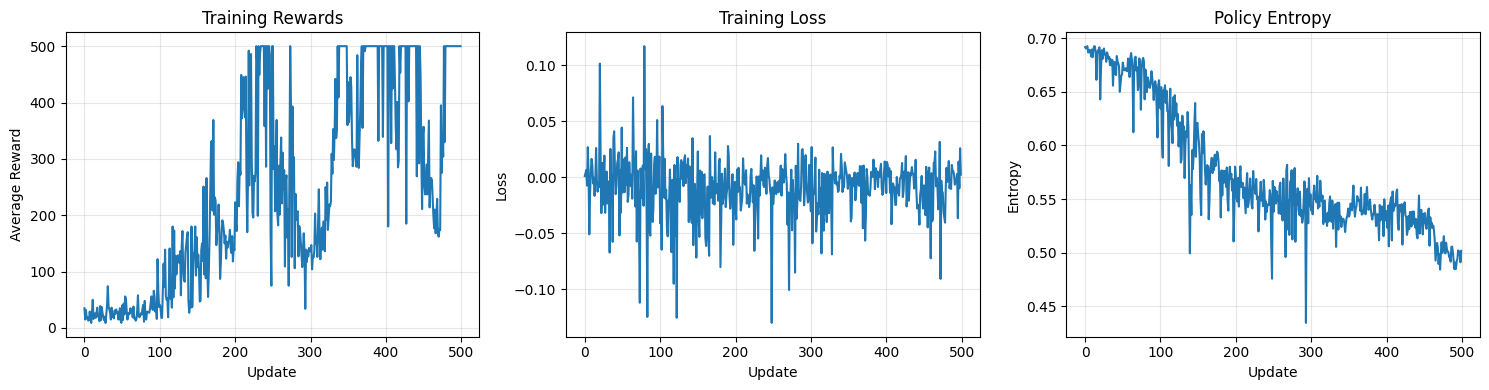


EVALUATION
Episode 1: Reward = 500.0
Episode 2: Reward = 500.0
Episode 3: Reward = 500.0
Episode 4: Reward = 500.0
Episode 5: Reward = 500.0
Episode 6: Reward = 500.0
Episode 7: Reward = 500.0
Episode 8: Reward = 500.0
Episode 9: Reward = 500.0
Episode 10: Reward = 500.0

Evaluation Results:
Average Reward: 500.0 ± 0.0

Model saved to 'policy_cartpole.pth'


In [4]:

if __name__ == "__main__":
    # Train the policy
    policy, rewards, losses, entropies = train(
        episodes=500,
        batch_size=1,
        lr=1e-3,
        entropy_coef=0.0001,
        gamma=0.99
    )
    
    # Plot results
    plot_training(rewards, losses, entropies)
    
    # Evaluate trained policy
    print("\n" + "=" * 70)
    print("EVALUATION")
    print("=" * 70)
    evaluate_policy(policy, num_episodes=10, render=False)
    
    # Save the model
    torch.save(policy.state_dict(), 'policy_cartpole.pth')
    print("\nModel saved to 'policy_cartpole.pth'")